In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv'

print("Loading dataset into RAM...")
df = pd.read_csv(file_path, low_memory=False) 

print(f"Dataset loaded successfully! Shape: {df.shape}")
print(df['Attack_type'].value_counts())

Loading dataset into RAM...
Dataset loaded successfully! Shape: (2219201, 63)
Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64


In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

In [3]:
drop_columns = ["frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4","arp.dst.proto_ipv4", 
                "http.file_data","http.request.full_uri","icmp.transmit_timestamp", 
                "http.request.uri.query", "tcp.options","tcp.payload","tcp.srcport", 
                "tcp.dstport", "udp.port", "mqtt.msg"]

df_clean = df.drop(columns=drop_columns, errors='ignore')

df_clean.dropna(inplace=True)

/tmp/ipykernel_55/3183767897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='viridis')


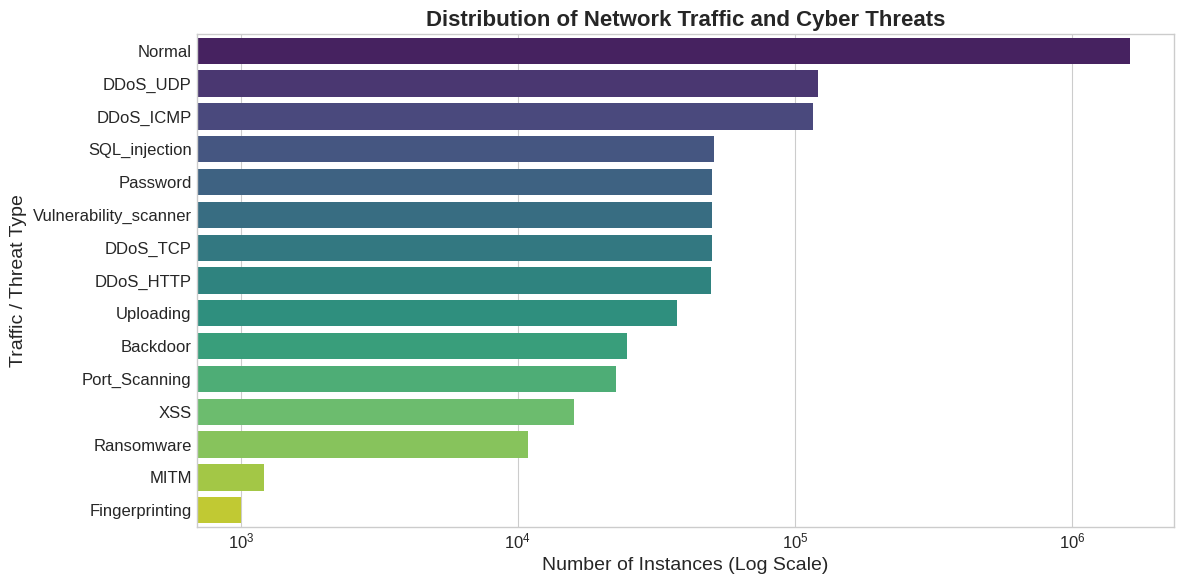

In [4]:
plt.figure(figsize=(12, 6))
attack_counts = df_clean['Attack_type'].value_counts()

ax = sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='viridis')
plt.title('Distribution of Network Traffic and Cyber Threats', fontsize=16, fontweight='bold')
plt.xlabel('Number of Instances (Log Scale)', fontsize=14)
plt.ylabel('Traffic / Threat Type', fontsize=14)

plt.xscale('log') 

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()

In [5]:

X = df_clean.drop(columns=['Attack_type'])
y = df_clean['Attack_type']

X_encoded = pd.get_dummies(X) # One-Hot encoding 

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_encoded)

print(f"Data normalized! Final feature count: {X_normalized.shape[1]}")

Data normalized! Final feature count: 96


Encoding categorical data...
Calculating t-SNE... (this part takes about 1-2 minutes)


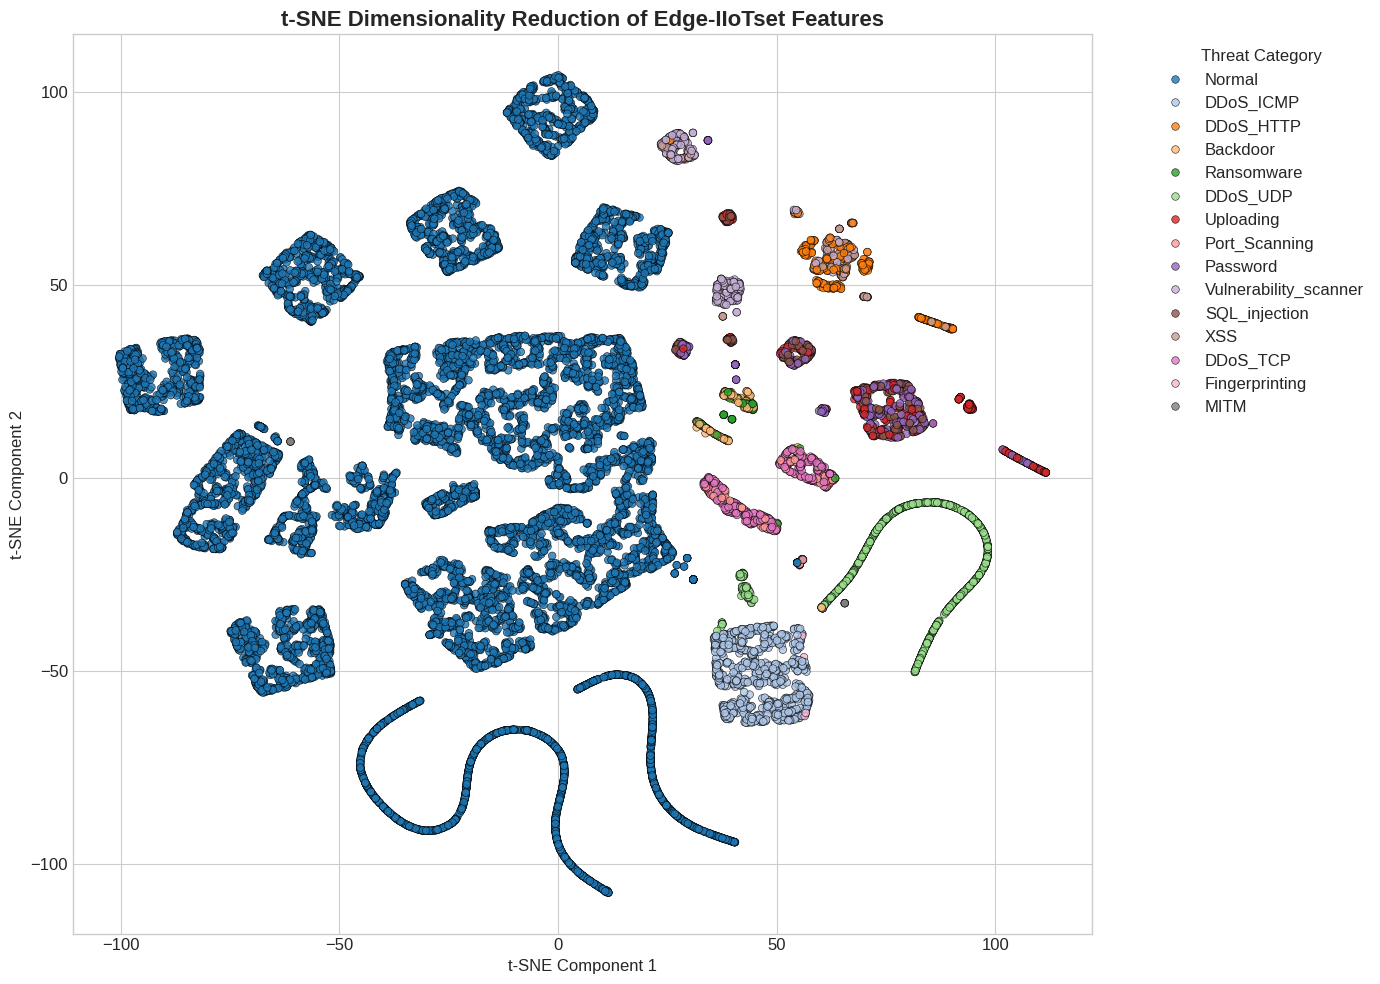

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Convert any text strings into numbers (One-Hot Encoding)
# This will turn a column with 'GET' into a binary column of 0s and 1s
print("Encoding categorical data...")
X_numeric = pd.get_dummies(X)

# 2. Take a stratified sample (Lightning Fast!)
sample_size = 15000
X_sample, _, y_sample, _ = train_test_split(
    X_numeric, y, 
    train_size=sample_size, 
    stratify=y, 
    random_state=42
)

# 3. Standardize the data (Crucial for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# 4. Apply t-SNE to squash dimensions down to 2
print("Calculating t-SNE... (this part takes about 1-2 minutes)")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

# 5. Plot the results
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_sample,
    palette="tab20",
    s=30, alpha=0.8, edgecolor="k"
)

plt.title("t-SNE Dimensionality Reduction of Edge-IIoTset Features", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Threat Category")
plt.tight_layout()

# Save for your LaTeX document!
plt.savefig("tsne_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Rebuilding dataset with strict temporal isolation...")

encoder = LabelEncoder()
df_clean['label_encoded'] = encoder.fit_transform(df_clean['Attack_type'])

train_list = []
test_list = []

for attack in df_clean['Attack_type'].unique():
    subset = df_clean[df_clean['Attack_type'] == attack]
    split_idx = int(len(subset) * 0.8) 
    
    train_list.append(subset.iloc[:split_idx])
    test_list.append(subset.iloc[split_idx:])

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

drop_cols = ['Attack_type', 'label_encoded']
X_train_raw = train_df.drop(columns=drop_cols)
y_train_raw = train_df['label_encoded'].values

X_test_raw = test_df.drop(columns=drop_cols)
y_test_raw = test_df['label_encoded'].values

X_train_encoded = pd.get_dummies(X_train_raw)
X_test_encoded = pd.get_dummies(X_test_raw)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_encoded)
X_test_norm = scaler.transform(X_test_encoded) 

class IIoTSequenceDataset(Dataset):
    def __init__(self, X_data, y_data, sequence_length=50):
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long)
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, idx):
        window = self.X[idx : idx + self.seq_len]
        label = self.y[idx + self.seq_len - 1]
        return window, label

seq_len = 50
batch_size = 512

train_dataset = IIoTSequenceDataset(X_train_norm, y_train_raw, seq_len)
test_dataset = IIoTSequenceDataset(X_test_norm, y_test_raw, seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Isolated Train batches: {len(train_loader)} | Isolated Test batches: {len(test_loader)}")

Rebuilding dataset with strict temporal isolation...
Isolated Train batches: 3467 | Isolated Test batches: 867


In [12]:
import torch.nn as nn

class AdaptiveThreatModel(nn.Module):
    def __init__(self, num_features, num_classes, hidden_size=64, num_lstm_layers=2):
        super(AdaptiveThreatModel, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        self.lstm = nn.LSTM(
            input_size=32, 
            hidden_size=hidden_size, 
            num_layers=num_lstm_layers, 
            batch_first=True,
            dropout=0.2 # Prevents overfitting
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)
        
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x) 
        
        x = x.transpose(1, 2)
        
        lstm_out, (hn, cn) = self.lstm(x)
        
        last_hidden = lstm_out[:, -1, :]
        
        out = self.fc(last_hidden)
        return out

actual_num_features = X_train_norm.shape[1]
print(f"Initializing model with {actual_num_features} features...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdaptiveThreatModel(num_features=actual_num_features, num_classes=num_classes).to(device)

import torch.optim as optim
learning_rate = 0.001
l2_penalty = 1e-4  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)

print(f"Model and Optimizer ready on {device}")

Initializing model with 82 features...
Model and Optimizer ready on cuda


In [13]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report
import time

learning_rate = 0.001
l2_penalty = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_penalty)

num_epochs = 10
print(f"Starting Training on {device}...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    
    for i, (windows, labels) in enumerate(train_loader):
        windows, labels = windows.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(windows)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if (i + 1) % 500 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
            
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for windows, labels in test_loader:
            windows = windows.to(device)
            outputs = model(windows)
            
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_time = time.time() - start_time
    
    print(f"=== Epoch {epoch+1} Complete | Time: {epoch_time:.2f}s | Test Accuracy: {epoch_acc * 100:.2f}% ===")

print("\nTraining Complete! Generating Final Classification Report...")
print(classification_report(all_targets, all_preds, target_names=encoder.classes_))

Starting Training on cuda...
Epoch [1/10], Batch [500/3467], Loss: 0.0154
Epoch [1/10], Batch [1000/3467], Loss: 0.0028
Epoch [1/10], Batch [1500/3467], Loss: 0.0012
Epoch [1/10], Batch [2000/3467], Loss: 0.0010
Epoch [1/10], Batch [2500/3467], Loss: 0.0005
Epoch [1/10], Batch [3000/3467], Loss: 0.0008
=== Epoch 1 Complete | Time: 74.20s | Test Accuracy: 99.21% ===
Epoch [2/10], Batch [500/3467], Loss: 0.0005
Epoch [2/10], Batch [1000/3467], Loss: 0.0009
Epoch [2/10], Batch [1500/3467], Loss: 0.0009
Epoch [2/10], Batch [2000/3467], Loss: 0.0005
Epoch [2/10], Batch [2500/3467], Loss: 0.0004
Epoch [2/10], Batch [3000/3467], Loss: 0.0005
=== Epoch 2 Complete | Time: 74.42s | Test Accuracy: 99.58% ===
Epoch [3/10], Batch [500/3467], Loss: 0.0003
Epoch [3/10], Batch [1000/3467], Loss: 0.0005
Epoch [3/10], Batch [1500/3467], Loss: 0.0005
Epoch [3/10], Batch [2000/3467], Loss: 0.0083
Epoch [3/10], Batch [2500/3467], Loss: 0.0004
Epoch [3/10], Batch [3000/3467], Loss: 0.0005
=== Epoch 3 Comple

In [ ]:
import torch
import os

print("Initiating Post-Training Quantization and Export...")

model.eval()

model_cpu = model.to('cpu')

quantized_model = torch.quantization.quantize_dynamic(
    model_cpu, 
    {torch.nn.LSTM, torch.nn.Linear}, 
    dtype=torch.qint8
)
print("Model successfully quantized to 8-bit integers.")

input_data = torch.randn(1, sequence_length, actual_num_features)

traced_script_module = torch.jit.trace(quantized_model, input_data)

export_path = "adaptive_edge_engine.pt"
traced_script_module.save(export_path)

final_size_mb = os.path.getsize(export_path) / 1e6
print(f"Serialized TorchScript model saved to: {export_path}")
print(f"Deployment Ready! Final footprint: {final_size_mb:.2f} MB")

Initiating Post-Training Quantization and Export...
Model successfully quantized to 8-bit integers.


/tmp/ipykernel_55/2162539872.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Serialized TorchScript model saved to: adaptive_edge_engine.pt
Deployment Ready! Final footprint: 0.12 MB


In [15]:
import pandas as pd
from sklearn.metrics import classification_report

print("Generating downloadable inference reports...")

report_dict = classification_report(
    all_targets, 
    all_preds, 
    target_names=encoder.classes_, 
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
csv_path = "inference_metrics_report.csv"
report_df.to_csv(csv_path)

txt_path = "inference_report_readable.txt"
with open(txt_path, "w") as text_file:
    text_file.write("=== Adaptive Threat Model: Final Inference Report ===\n\n")
    text_file.write(classification_report(
        all_targets, 
        all_preds, 
        target_names=encoder.classes_
    ))

print(f"Success! Your reports are ready for download:")
print(f" -> Table Format: {csv_path}")
print(f" -> Text Format:  {txt_path}")

Generating downloadable inference reports...
Success! Your reports are ready for download:
 -> Table Format: inference_metrics_report.csv
 -> Text Format:  inference_report_readable.txt


Loading serialized TorchScript model...
Model loaded successfully!
Running inference on test data. This may take a minute...
Inference complete! Generating confusion matrix...


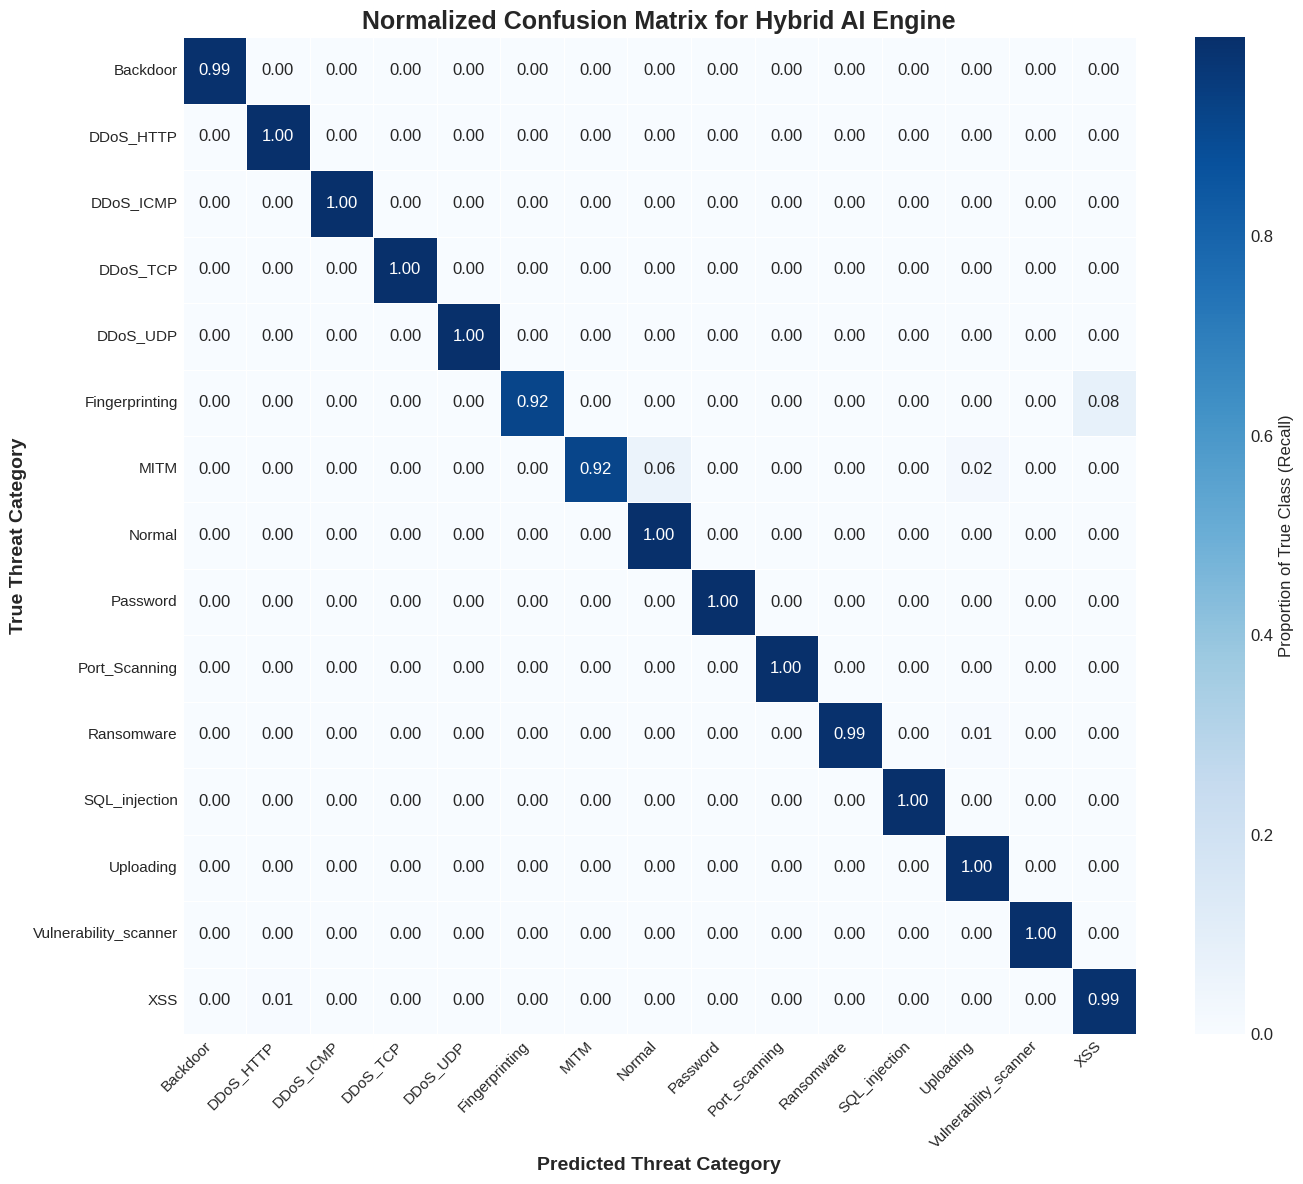

Success! Download 'confusion_matrix.png' to add to your paper.


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Loading serialized TorchScript model...")

model_path = '/kaggle/input/models/hussainhaidary/adaptive-edge-engine/pytorch/default/1/adaptive_edge_engine.pt'
loaded_model = torch.jit.load(model_path, map_location=torch.device('cpu'))
loaded_model.eval() # Ensure it's in evaluation mode
print("Model loaded successfully!")

print("Running inference on test data. This may take a minute...")
all_preds = []
all_targets = []

with torch.no_grad():
    for windows, labels in test_loader:
        windows = windows.to('cpu')
        
        outputs = loaded_model(windows)
        
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.numpy())
        all_targets.extend(labels.numpy())

print("Inference complete! Generating confusion matrix...")

cm = confusion_matrix(all_targets, all_preds)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

# 4. Plot the Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            cbar_kws={'label': 'Proportion of True Class (Recall)'},
            linewidths=.5)

plt.title('Normalized Confusion Matrix for Hybrid AI Engine', fontsize=18, fontweight='bold')
plt.ylabel('True Threat Category', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Threat Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("Success! Download 'confusion_matrix.png' to add to your paper.")

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class AdaptiveLearningLoop:
    def __init__(self, model, tau=0.85, retrain_batch_size=512, lr=0.001):
        """
        Initializes the Adaptive Threat Modeler for edge deployment.
        """
        self.model = model
        self.tau = tau
        self.retrain_batch_size = retrain_batch_size
        
        # Threat Archive
        self.archive_x = []
        self.archive_y = []
        
        self.device = next(model.parameters()).device
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4) # L2 Regularization
        self.criterion = nn.CrossEntropyLoss()

    def process_telemetry(self, x_tensor):
        """
        Simulates the C++ Inference Engine processing new streaming data.
        """
        self.model.eval()
        with torch.no_grad():
            x_tensor = x_tensor.to(self.device)
            logits = self.model(x_tensor)
            
            probabilities = torch.softmax(logits, dim=1)
            max_probs, predicted_classes = torch.max(probabilities, dim=1)

        novel_threats_flagged = 0
        
        # Evaluate against the empirical threshold (tau)
        for i in range(len(max_probs)):
            if max_probs[i] < self.tau:
                # Confidence is low: Flag as Novel Threat and Archive
                self.archive_x.append(x_tensor[i].cpu())
                self.archive_y.append(predicted_classes[i].cpu()) 
                novel_threats_flagged += 1
                
        print(f"Processed {len(x_tensor)} packets | High Confidence: {len(x_tensor) - novel_threats_flagged} | Novel Threats Archived: {novel_threats_flagged}")
        
        # Check if the archive has enough data to trigger a weight update
        if len(self.archive_x) >= self.retrain_batch_size:
            self.trigger_weight_update()

    def trigger_weight_update(self):
        """
        Executes the dynamic weight update (theta <- theta - eta * grad(J))
        """
        print(f"\n[ALERT] Archive reached {len(self.archive_x)} samples. Triggering Adaptive Learning Loop...")
        self.model.train()
        
        # Prepare the archived dataset
        X_train = torch.stack(self.archive_x).to(self.device)
        y_train = torch.stack(self.archive_y).to(self.device)
        
        dataset = TensorDataset(X_train, y_train)
        dataloader = DataLoader(dataset, batch_size=self.retrain_batch_size, shuffle=True)
        
        # Empirical Risk Minimization (Fine-tuning)
        for batch_x, batch_y in dataloader:
            self.optimizer.zero_grad()
            outputs = self.model(batch_x)
            loss = self.criterion(outputs, batch_y)
            loss.backward()
            self.optimizer.step()
            
        print("[SUCCESS] Threat model parameters dynamically updated.")
        
        # Clear the archive after learning to prevent staleness
        self.archive_x = []
        self.archive_y = []
        print("[STATUS] Threat archive cleared. Resuming standard inference.\n")

In [ ]:
import torch
import numpy as np

def create_sequences(data, seq_length=20):
    sequences = []
    data_array = data.values if hasattr(data, 'values') else data
    
    for i in range(len(data_array) - seq_length):
        sequences.append(data_array[i : i + seq_length])
        
    return np.array(sequences)

print("Formulating T=20 temporal sequences. This might take a few seconds...")

X_test_seq = create_sequences(X_test_norm, seq_length=20)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)

print(f"Successfully created Tensor with shape: {X_test_tensor.shape}")

print("Shuffling edge telemetry to simulate varied attack vectors...")
indices = torch.randperm(X_test_tensor.size(0))
X_test_shuffled = X_test_tensor[indices]

adaptive_system = AdaptiveLearningLoop(model=loaded_model, tau=0.95, retrain_batch_size=128)

print("\n--- Starting Real-Time Edge Inference Simulation ---")
chunk_size = 250

for i in range(0, 7000, chunk_size):
    streaming_batch = X_test_shuffled[i : i + chunk_size]
    adaptive_system.process_telemetry(streaming_batch)

print("\n--- Adaptive learning loop finished ---")

Formulating T=20 temporal sequences. This might take a few seconds...
Successfully created Tensor with shape: torch.Size([443826, 20, 82])
Shuffling edge telemetry to simulate varied attack vectors...

--- Starting Real-Time Edge Inference Simulation ---
Processed 250 packets | High Confidence: 243 | Novel Threats Archived: 7
Processed 250 packets | High Confidence: 238 | Novel Threats Archived: 12
Processed 250 packets | High Confidence: 248 | Novel Threats Archived: 2
Processed 250 packets | High Confidence: 243 | Novel Threats Archived: 7
Processed 250 packets | High Confidence: 242 | Novel Threats Archived: 8
Processed 250 packets | High Confidence: 242 | Novel Threats Archived: 8
Processed 250 packets | High Confidence: 240 | Novel Threats Archived: 10
Processed 250 packets | High Confidence: 247 | Novel Threats Archived: 3
Processed 250 packets | High Confidence: 249 | Novel Threats Archived: 1
Processed 250 packets | High Confidence: 244 | Novel Threats Archived: 6
Processed 250